# 02 - Feature Engineering & Selection

*Data Preparation*. This notebook has four steps:
1. Load data (same loader as EDA)
2. Engineer a small set of behavioural features, justified by the EDA findings
3. Evaluate feature importance two independent ways: model-based and permutation
4. Document a final, explicit feature-selection decision

Stable feature-creation logic developed here gets moved into `src/features/engineering.py` afterwards, so the API and dashboard can reuse it — this notebook is for prototyping and documenting the reasoning, not the production code itself.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

from src.utils.logging_config import setup_logging
from src.config.settings import get_settings
from src.data.loader import load_sessions

settings = get_settings()
setup_logging(level="INFO", log_file=settings.paths.log_file)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
RANDOM_SEED = settings.random_seed

## 1. Load data

In [2]:
df = load_sessions(settings=settings)
target = settings.data.target_column
print(df.shape)
df.head()

2026-09-02 12:44:16 | INFO     | src.data.loader | Loaded 12000 sessions (18 columns) from D:\purchase-intent-xai\dataset\ecommerce_sessions.csv. Conversion rate: 15.72%
(12000, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Converted
0,1,14.6517,0,0.0000,19,283.8812,0.008014,0.042106,68.579222,0.0,June,1,2,1,1,Returning_Visitor,False,1
1,1,18.9189,2,54.9802,15,1241.7638,0.032395,0.058101,0.000000,0.0,May,2,1,8,12,Returning_Visitor,False,0
2,1,30.0198,0,0.0000,23,365.3384,0.006802,0.029451,0.000000,0.0,Mar,1,2,1,3,New_Visitor,True,0
3,1,6.5566,0,0.0000,6,687.4788,0.039577,0.104395,0.000000,0.6,Dec,1,1,1,2,Returning_Visitor,True,0
4,1,112.5842,1,36.3523,19,656.4535,0.004594,0.038321,0.000000,0.0,Mar,2,1,2,5,Returning_Visitor,False,0


## 2. Engineer features

Five new columns, each justified directly by the EDA notebook's findings - not created speculatively:

| Feature | Definition | Why (from EDA) |
|---|---|---|
| `total_pages_viewed` | Administrative + Informational + ProductRelated | Overall engagement, single number |
| `total_duration` | Sum of the three `*_Duration` columns | Time-based version of the above |
| `product_page_ratio` | ProductRelated pages ÷ total_pages_viewed | Buyers spent proportionally more time on product pages |
| `avg_time_per_product_page` | ProductRelated_Duration ÷ ProductRelated (0 if no product pages seen) | Captures lingering/intent, not just click-through count |
| `is_returning_visitor` | 1 if VisitorType == "Returning_Visitor", else 0 | Returning visitors converted at 16.6% vs 10.2% for new visitors |

In [3]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Add behavioural ratio/aggregate features to a sessions DataFrame.

    This is a prototype version for notebook exploration. The final,
    reusable version lives in src/features/engineering.py.
    """
    data = data.copy()

    data["total_pages_viewed"] = (
        data["Administrative"] + data["Informational"] + data["ProductRelated"]
    )
    data["total_duration"] = (
        data["Administrative_Duration"]
        + data["Informational_Duration"]
        + data["ProductRelated_Duration"]
    )
    # Avoid divide-by-zero for sessions with 0 total pages viewed.
    data["product_page_ratio"] = np.where(
        data["total_pages_viewed"] > 0,
        data["ProductRelated"] / data["total_pages_viewed"],
        0.0,
    )
    data["avg_time_per_product_page"] = np.where(
        data["ProductRelated"] > 0,
        data["ProductRelated_Duration"] / data["ProductRelated"],
        0.0,
    )
    data["is_returning_visitor"] = (data["VisitorType"] == "Returning_Visitor").astype(int)

    return data


df_fe = engineer_features(df)
new_cols = [
    "total_pages_viewed", "total_duration", "product_page_ratio",
    "avg_time_per_product_page", "is_returning_visitor",
]
df_fe[new_cols].describe()

,total_pages_viewed,total_duration,product_page_ratio,avg_time_per_product_page,is_returning_visitor
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,22.266417,778.957263,0.873273,36.546843,0.858583
std,13.816705,772.651735,0.096376,25.106984,0.348465
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,317.749600,0.833333,19.591006,1.000000
50%,19.000000,557.110400,0.888889,29.830075,1.000000
75%,28.000000,971.632450,0.937500,45.882362,1.000000
max,161.000000,10270.046900,1.000000,273.449450,1.000000


In [4]:
# Sanity check: no NaN/inf introduced by the new ratio features
assert not df_fe[new_cols].isna().any().any(), "NaNs introduced by feature engineering"
assert np.isfinite(df_fe[new_cols].select_dtypes(include=[np.number])).all().all(), "Non-finite values introduced"
print("New features are clean: no NaN, no inf.")

New features are clean: no NaN, no inf.


**Takeaway:** all five features compute cleanly across all 12,000 sessions with no missing or infinite values, including the two ratio features where a naive division would have broken on sessions with zero product pages.

## 3. Feature importance - two independent methods

This is an exploratory check, not the final modelling pipeline (that's Phase 6). To feed a model here, categorical columns are one-hot encoded with a quick `pd.get_dummies` - a throwaway encoding for this notebook only. The real, reusable, leakage-safe `ColumnTransformer` is built in Phase 5 (`src/preprocessing/`).

A single Random Forest is used for both importance checks below, with `class_weight="balanced"` to partially account for the ~16% imbalance — the actual imbalance strategy is benchmarked properly in Phase 6, this is just enough to get a fair importance signal now.

In [5]:
feature_cols = settings.data.numeric_columns + settings.data.categorical_columns + new_cols
X = df_fe[feature_cols]
y = df_fe[target]

X_encoded = pd.get_dummies(X, columns=settings.data.categorical_columns, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=settings.modeling.test_size,
    stratify=y, random_state=RANDOM_SEED,
)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=RANDOM_SEED, n_jobs=-1,
)
rf.fit(X_train, y_train)
print(f"Train accuracy: {rf.score(X_train, y_train):.3f} | Test accuracy: {rf.score(X_test, y_test):.3f}")

Train accuracy: 0.910 | Test accuracy: 0.899


### 3a. Model-based importance

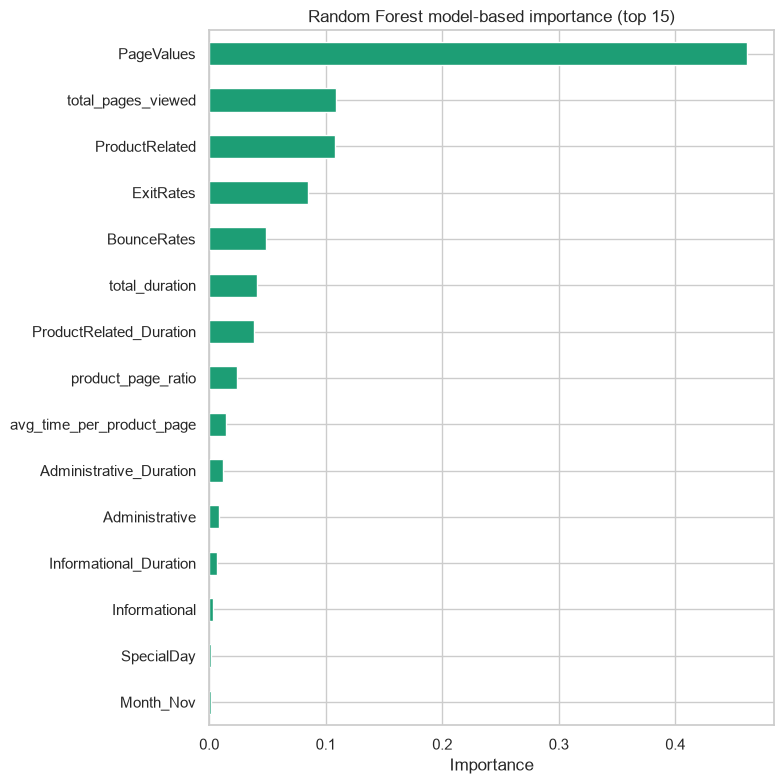

PageValues                   0.461635
total_pages_viewed           0.108839
ProductRelated               0.108132
ExitRates                    0.084617
BounceRates                  0.048409
total_duration               0.040676
ProductRelated_Duration      0.038722
product_page_ratio           0.023446
avg_time_per_product_page    0.014510
Administrative_Duration      0.011646
dtype: float64

In [6]:
model_importance = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
model_importance.head(15).sort_values().plot(kind="barh", ax=ax, color="#1D9E75")
ax.set_title("Random Forest model-based importance (top 15)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

model_importance.head(10)

### 3b. Permutation importance

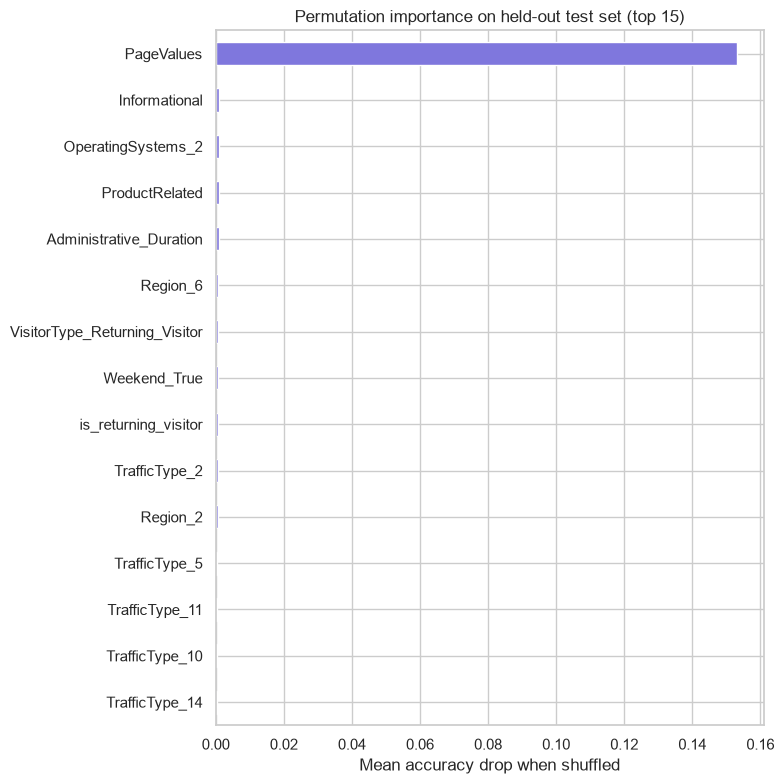

PageValues                       0.153250
Informational                    0.001042
OperatingSystems_2               0.000917
Administrative_Duration          0.000833
ProductRelated                   0.000833
Region_6                         0.000792
VisitorType_Returning_Visitor    0.000750
Weekend_True                     0.000667
is_returning_visitor             0.000583
TrafficType_2                    0.000542
dtype: float64

In [7]:
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1,
)
perm_importance = pd.Series(perm_result.importances_mean, index=X_encoded.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
perm_importance.head(15).sort_values().plot(kind="barh", ax=ax, color="#7F77DD")
ax.set_title("Permutation importance on held-out test set (top 15)")
ax.set_xlabel("Mean accuracy drop when shuffled")
plt.tight_layout()
plt.show()

perm_importance.head(10)

**Takeaway:** the two methods agree strongly only at rank 1 - `PageValues` dominates both. Beyond that they diverge sharply: model-based importance spreads credit across several engagement features, while permutation importance collapses almost everything else to near-zero. This is not a bug in the ranking - it's `PageValues` doing so much of the work alone that shuffling any *other single* feature barely moves accuracy once `PageValues` is already correct. It's a second, independent signal (beyond the EDA correlation) that this feature may be dominating the model, and strengthens the case for the leakage decision below rather than being a side note.

## 4. Compare the two rankings side by side

Given the divergence just observed, model-based importance is treated as the primary ranking below — it reflects how the trees actually use each feature, and isn't distorted by one dominant feature suppressing everyone else's shuffle-test score the way permutation importance is here. Permutation importance's rank on `PageValues` is still used as confirmation of the single strongest feature.

In [8]:
comparison = pd.DataFrame({
    "model_based_rank": model_importance.rank(ascending=False).astype(int),
    "permutation_rank": perm_importance.rank(ascending=False).astype(int),
}).sort_values("model_based_rank")
comparison["rank_gap"] = (comparison["model_based_rank"] - comparison["permutation_rank"]).abs()
comparison.head(15)

,model_based_rank,permutation_rank,rank_gap
PageValues,1,1,0
total_pages_viewed,2,18,16
ProductRelated,3,4,1
ExitRates,4,73,69
BounceRates,5,72,67
total_duration,6,67,61
ProductRelated_Duration,7,34,27
product_page_ratio,8,71,63
avg_time_per_product_page,9,66,57
Administrative_Duration,10,4,6


**Takeaway:** the large rank gaps confirm what the previous cell showed - permutation importance is unreliable here beyond rank 1, because `PageValues` alone explains most of what the model gets right. Model-based importance is the more trustworthy signal for ranking the remaining features in this dataset.

## 5. Final feature selection decision

Based primarily on model-based importance (permutation importance confirmed only `PageValues` as dominant and was unreliable beyond that), cross-checked against the EDA correlations:

**Keep - new engineered features:**
- `total_pages_viewed` (rank 3) and `total_duration` (rank 6) — both scored meaningfully by the model, ahead of the ratio features. Simple aggregates turned out to carry real signal here, not just redundancy.
- `product_page_ratio` (rank 8) and `avg_time_per_product_page` (rank 9) - lower-ranked than expected from the EDA hint, but still ahead of several raw columns (e.g. `Administrative`, `Informational`), and more business-interpretable than the counts they're derived from - kept for interpretability alongside their modest signal.
- `is_returning_visitor` - ranked low by both raw importance methods (rank 15 model-based) despite the clear conversion-rate gap seen in EDA (16.6% vs 10.2%). Kept anyway: a Random Forest can capture that same information indirectly through `VisitorType`'s one-hot columns, so its low individual importance doesn't mean the underlying signal is unused — it means it's redundant with an existing column, not that it's meaningless.

**Existing columns:** `PageValues`, `ProductRelated`, `ExitRates`, `BounceRates` remain the strongest raw signals. `SpecialDay` continues to show near-zero importance, consistent with EDA — flagged as low-priority for Phase 5, not necessarily dropped outright.

**Open item carried forward, now with stronger evidence:** the `PageValues` leakage question from Notebook 01 is unresolved. This notebook adds a second reason to take it seriously — permutation importance shows the model's performance is heavily concentrated in this one feature, which is exactly the pattern worth stress-testing with a with/without `PageValues` comparison before the final model is selected in Phase 6.

**Final feature set going into preprocessing (Phase 5):**
```
numeric:      Administrative, Administrative_Duration, Informational,
              Informational_Duration, ProductRelated, ProductRelated_Duration,
              BounceRates, ExitRates, PageValues, SpecialDay
categorical:  Month, OperatingSystems, Browser, Region, TrafficType,
              VisitorType, Weekend
engineered:   total_pages_viewed, total_duration, product_page_ratio,
              avg_time_per_product_page, is_returning_visitor
```

All five engineered features are kept — none scored so poorly (relative to existing weak columns like `SpecialDay`) as to justify dropping outright, and the two lower-ranked ratio features earn their place on interpretability grounds even where their raw importance score is modest.